## Support Vector Regressor Implementation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## Lets create synthetic data points
from sklearn.datasets import make_regression

In [3]:
X,y=make_regression(n_samples=1000,n_features=2,n_targets=1,noise=3.0)

In [4]:
X

array([[-0.49009382,  1.71718749],
       [-1.25569563,  1.02613527],
       [-1.03190741, -1.64081355],
       ...,
       [-0.7645217 , -1.42438521],
       [ 0.16309437, -1.20626567],
       [-1.25591481, -1.61235421]], shape=(1000, 2))

In [5]:
y

array([ 7.85127265e+01, -4.85474857e+01, -2.14354647e+02,  5.99077792e+01,
        1.40786148e+02,  1.75253562e+02, -2.03620966e+02,  2.74450089e+01,
        1.17123234e+02, -6.84941198e+00,  3.06896724e+02, -1.42850454e+02,
       -1.76612047e+02, -1.21913570e+02, -9.01353974e+01, -2.05235368e+02,
       -4.05158874e+01,  8.40846198e+01, -1.41640522e+02,  8.25049460e+00,
       -8.53925092e+01,  2.77795415e+01, -1.42765519e+02,  1.27378291e+02,
       -4.56778608e+01, -4.42343967e+01,  2.91539460e+01, -8.95482641e+01,
       -3.40434102e+02,  1.37157353e+02, -3.05791758e+01, -3.36267647e+01,
       -3.01801029e+01,  3.16718176e+01, -1.20638009e+02, -1.39681828e+01,
        2.21449536e+01,  3.87605556e+01, -1.97674091e+00, -7.17959024e+01,
        1.38277767e+02, -4.05640373e+01, -2.71901255e+02,  1.26558752e+02,
       -8.59770532e+01,  1.79511855e+02,  6.81978466e+01, -1.43387449e+02,
        6.93496711e+01,  1.23336821e+02,  8.18198000e+01,  9.01211068e+01,
        2.14162425e+01,  

In [6]:
pd.DataFrame(X)[0]

0     -0.490094
1     -1.255696
2     -1.031907
3      1.326687
4      1.595470
         ...   
995   -1.500472
996    0.306622
997   -0.764522
998    0.163094
999   -1.255915
Name: 0, Length: 1000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

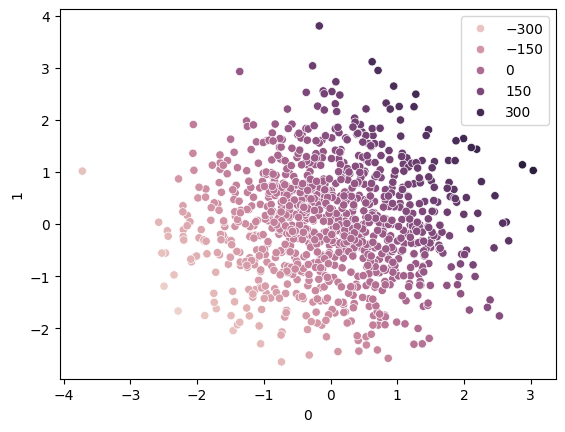

In [7]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=10)

In [9]:
from sklearn.svm import SVR

In [10]:
svr=SVR(kernel='linear')

In [11]:
svr.fit(X_train,y_train)

SVR(kernel='linear')

In [12]:
svr.coef_

array([[97.41546626, 69.9593188 ]])

In [13]:
## Prediction
y_pred=svr.predict(X_test)

In [14]:
y_pred

array([ 3.15905475e+01, -6.17821257e+00,  1.06448236e+02,  1.18586086e+02,
        1.65553833e+01, -3.72463383e+01, -1.42315991e+02, -4.33808423e+01,
       -1.42366306e+02,  3.61820681e+01, -7.38637042e+01,  1.68490050e+02,
        1.49821667e+02, -9.92602059e+01,  2.95246136e+02,  2.01317865e+02,
        1.00068722e+02,  1.41059627e+02, -2.03331808e+02,  1.80270144e+02,
        8.01618984e+01, -1.04846219e+01, -1.09308441e+02,  5.03459373e+00,
       -1.53153802e+02, -4.93769898e+01,  5.29873083e+01, -1.64033377e+01,
       -2.40049417e+01,  1.21559830e+01,  3.16002062e+01,  2.79111512e+02,
        1.20091317e+02, -9.32296048e+01,  3.28222018e+01, -4.31576737e+01,
       -1.98921178e+02, -1.63138285e+01, -7.84827454e+01,  2.30541478e+01,
        9.46881892e+01,  1.37358846e+02, -1.80771975e+02, -7.90216118e+01,
        9.23483820e+01,  6.36516314e+01,  1.63381986e+02, -1.12405623e+02,
        1.36785170e+02, -3.74049408e+01, -8.90014274e+01,  1.86757383e+02,
       -5.29597781e+01,  

In [15]:
from sklearn.metrics import r2_score

In [ ]:
print(r2_score(y_test, y_pred))

0.999415487409269


## Hyperparametere Tuning With SVR

In [17]:
from sklearn.model_selection import GridSearchCV

# defining parameter range
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel':['linear'],
              'epsilon':[0.1,0.2,0.3]
              }

In [ ]:
grid = GridSearchCV(SVR(), param_grid=param_grid, refit=True, cv=5, verbose=3)

In [19]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 75 candidates, totalling 375 fits
[CV 1/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.609 total time=   0.0s
[CV 2/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.631 total time=   0.0s
[CV 3/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.624 total time=   0.0s
[CV 4/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.625 total time=   0.0s
[CV 5/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.638 total time=   0.0s
[CV 1/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.609 total time=   0.0s
[CV 2/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.631 total time=   0.0s
[CV 3/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.624 total time=   0.0s
[CV 4/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.625 total time=   0.0s
[CV 5/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.638 total time=   0.0s
[CV 1/5] END C=0.1, epsilon=0.1, gamma

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'epsilon': [0.1, 0.2, 0.3],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['linear']},
             verbose=3)

In [20]:
grid.best_params_

{'C': 1000, 'epsilon': 0.2, 'gamma': 1, 'kernel': 'linear'}

In [21]:
## Prediction
y_pred4=grid.predict(X_test)
print(r2_score(y_test,y_pred4))

0.9994538473201097
